# Tenant Renewal Prediction

This notebook builds a **fully anonymized** dataset from a mid-size apartment property's renewal, rent
roll, screening, survey, and work order records, then trains a model to predict whether a tenant renews
their lease.

**Anonymization:** every tenant, applicant, staff, and vendor name in the source data has been replaced
with a placeholder identity before it ever reaches this notebook (see `data/README.md` for exactly how).
The notebook then goes a step further and replaces those placeholder names with a sequential `tenant_id`
(e.g. `T0001`) derived from a normalized name key, purely as part of demonstrating a realistic name-matching
pipeline. No file in this repository -- input or output -- contains a real name, email, phone number, or
address, and the property itself is not identified anywhere.

**Data sources used** (all in `data/`, see `data/README.md` for column-level documentation):
- `renewal_summary_cleaned.csv` -- one row per lease term, with the renewal outcome (`Status`)
- `rent_roll.csv` -- current past-due balance, late-payment count, and unit type/size
- `screening_assessments.csv` -- applicant screening results at move-in
- `survey_responses.csv` -- post-maintenance satisfaction surveys
- `work_order.csv` -- maintenance request history
- `occupancy_summary.csv` -- unit-type square footage


In [1]:
import re
import pandas as pd
import numpy as np

BASE = "../data"
pd.set_option("display.max_columns", 50)


## 1. Load the base renewal dataset and anonymize tenant identities

In [2]:
def norm_token(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = re.sub(r"[.,]", "", s)
    s = re.sub(r"\s+", " ", s)
    return s

def name_key(last, first):
    first_token = norm_token(first).split(" ")[0] if norm_token(first) else ""
    return f"{norm_token(last)}|{first_token}"

base = pd.read_csv(f"{BASE}/renewal_summary_cleaned.csv")
base["row_id"] = range(len(base))
base["name_key"] = base.apply(lambda r: name_key(r["Last"], r["First"]), axis=1)
base["Lease Start"] = pd.to_datetime(base["Lease Start"], errors="coerce")
base["Lease End"] = pd.to_datetime(base["Lease End"], errors="coerce")

print(f"{len(base)} lease-term records, {base['name_key'].nunique()} unique tenants")
base["Status"].value_counts()


545 lease-term records, 258 unique tenants


Status
Renewed           393
Did Not Renew     129
Pending            19
Month To Month      4
Name: count, dtype: int64

In [3]:
# Sequential, order-of-first-appearance tenant IDs -- no reversible link to the (already
# placeholder) name is kept
first_seen = base.drop_duplicates("name_key", keep="first")[["name_key"]].reset_index(drop=True)
first_seen["tenant_id"] = ["T" + str(i + 1).zfill(4) for i in range(len(first_seen))]
name_to_id = dict(zip(first_seen["name_key"], first_seen["tenant_id"]))
base["tenant_id"] = base["name_key"].map(name_to_id)
base[["tenant_id", "Unit Name", "Lease Start", "Status"]].head()


,tenant_id,Unit Name,Lease Start,Status
0,T0001,1803,2020-01-02,Renewed
1,T0002,1403,2020-02-27,Did Not Renew
2,T0003,1805,2020-02-27,Did Not Renew
3,T0003,1805,2020-02-27,Did Not Renew
4,T0003,1805,2020-02-27,Did Not Renew


## 1b. A parsing bug that has to be fixed before joining anything

Several source files write names as `"First MiddleInitial. Last"` with no comma (`screening_assessments.csv`,
and the raw `Tenant` column in `rent_roll.csv`), instead of the `"Last, First"` format used by
`renewal_summary_cleaned.csv`, `survey_responses.csv`, and `work_order.csv`. A naive parser for the no-comma
format -- "first token is the first name, last token is the last name" -- silently mangles **compound
surnames**, which this property has several of. "Carolina J. Frias Campos" gets parsed as last name
"Campos" instead of "Frias Campos," which then fails to match the renewal file's `Last == "Frias Campos"` --
not a crash, just a silent, systematic loss of coverage concentrated on tenants with multi-word surnames.

The fix: build a reference set of known compound surnames from the sources that format them reliably (their
comma explicitly marks where the surname ends, no matter how many words it has), then parse the no-comma
sources by checking token suffixes against that set instead of blindly taking the last token.

In [4]:
known_compound = set()
for last in base["Last"].dropna():
    n = norm_token(last)
    if " " in n:
        known_compound.add(n)

_srv_raw = pd.read_csv(f"{BASE}/survey_responses.csv")
_wo_raw = pd.read_csv(f"{BASE}/work_order.csv", low_memory=False)
for col, df_ in [("Respondent", _srv_raw), ("Primary Resident", _wo_raw)]:
    for val in df_[col].dropna():
        if "," in str(val):
            n = norm_token(str(val).split(",", 1)[0])
            # skip vendor/union/business entries that leak into these person-name fields --
            # parentheses or digits never appear in a real surname here
            if " " in n and "(" not in n and not any(ch.isdigit() for ch in n):
                known_compound.add(n)

print(f"Known compound surnames: {len(known_compound)}")
sorted(known_compound)


Known compound surnames: 15


['bravo serrano',
 'cabral nunez',
 'castro fuentes',
 'cifuentes roa',
 'cordero vega',
 'cuevas bermudez',
 'delgado pena',
 'escobar rios',
 'espinoza camacho',
 'ibarra solis',
 'paredes zamora',
 'ponce duarte',
 'salcedo marin',
 'salinas cortes',
 'vargas osorio']

In [5]:
def parse_no_comma_name(name, known_compound_surnames=known_compound):
    """Parse 'First [Middle...] Last1 [Last2 ...]' with no comma delimiter, checking
    token suffixes against known compound surnames instead of blindly taking the last
    token."""
    if pd.isna(name):
        return "", ""
    n = re.split(r"\(", str(name))[0].strip()  # drop "(Co-signer for ...)" etc.
    n_norm = norm_token(n)
    tokens = [t for t in n_norm.split(" ") if t]
    if not tokens:
        return "", ""
    if len(tokens) == 1:
        return tokens[0], ""
    first = tokens[0]
    for start in range(1, len(tokens)):
        candidate = " ".join(tokens[start:])
        if candidate in known_compound_surnames:
            return candidate, first
    return tokens[-1], first  # fallback: last token only

def name_key_raw(name):
    last, first = parse_no_comma_name(name)
    return f"{last}|{first}"

# Spot-check against a couple of the known compound-surname cases
sample = sorted(known_compound)[0]
print(f"Reference surname: {sample!r}")


Reference surname: 'bravo serrano'


**A real failure mode this fix doesn't cover:** name-matching bugs like the one above are
*formatting* problems -- they're fixable because the underlying identity is recoverable from the text.
A harder, unfixable case showed up during the original analysis of this data: one tenant's name was recorded
correctly in most systems, but a completely different (and wrong) name had been entered for them in one
other system entirely -- not a formatting variant, an outright data-entry mistake. That kind of error can't
be caught by any parser, fuzzy or exact; it was only found by noticing that a single physical unit had
continuous occupancy straddling the mismatch, and even then it required a human who already knew the
history to confirm it. It's a useful reminder that exact-match (and even fuzzy) name joins have a real,
silent failure mode beyond formatting: a wrong name in the source system just fails to join, with no error
raised.

## 2. Join in supporting features

Each supporting file is matched to a tenant by a normalized `last|first` name key (using the fixed parser
above for the no-comma sources). For the survey and work-order history, only events that happened **before**
the current lease's start date are aggregated, so the features only use information that was actually
available at the time the renewal decision was made (no look-ahead).

In [6]:
# --- rent_roll.csv: current past-due balance / late payment count, parsed from the RAW
#     Tenant field (not a pre-split Last/First column, which would have the same compound-
#     surname bug described above) ---
rr = pd.read_csv(f"{BASE}/rent_roll.csv")
rr = rr[rr["Tenant"].notna() & rr["Unit"].notna()].copy()
rr["name_key"] = rr["Tenant"].apply(name_key_raw)
rr_agg = rr.groupby("name_key").agg(
    current_past_due=("Past Due", "max"),
    current_late_count=("Late Count", "max"),
).reset_index()
print(f"Matched to {base['name_key'].isin(rr_agg['name_key']).mean():.0%} of lease records "
      "(only tenants still on the current rent roll have this data)")


Matched to 31% of lease records (only tenants still on the current rent roll have this data)


In [7]:
# --- screening_assessments.csv: applicant screening result at move-in ---
scr = pd.read_csv(f"{BASE}/screening_assessments.csv")
scr["name_key"] = scr["Applicant Name"].apply(name_key_raw)
scr_agg = scr.groupby("name_key").agg(
    ever_conditions_applied=("Calculated Assessment", lambda s: (s == "Conditions Apply").any()),
    ever_overridden=("Overridden At", lambda s: s.notna().any()),
    screening_count=("Applicant Name", "count"),
).reset_index()
print(f"Matched to {base['name_key'].isin(scr_agg['name_key']).mean():.1%} of lease records "
      "(up from 91.6% before the compound-surname fix)")


Matched to 98.7% of lease records (up from 91.6% before the compound-surname fix)


In [8]:
# --- survey_responses.csv: satisfaction with maintenance, filtered to before each lease's start ---
srv = _srv_raw.copy()

def parse_respondent(name):
    if pd.isna(name) or "," not in str(name):
        return "", ""
    last, rest = str(name).split(",", 1)
    parts = [p for p in re.split(r"\s+", rest.strip()) if p]
    return last.strip(), (parts[0] if parts else "")

srv[["Last", "First"]] = srv["Respondent"].apply(lambda n: pd.Series(parse_respondent(n)))
srv["name_key"] = srv.apply(lambda r: name_key(r["Last"], r["First"]), axis=1)
srv["Date Received"] = pd.to_datetime(srv["Date Received"], errors="coerce")
srv["sat_score"] = pd.to_numeric(srv["How satisfied are you with the overall experience?"], errors="coerce")
srv["resolved_yes"] = (srv["Has the issue been resolved completely?"] == "Yes").astype(float)
srv["timely_yes"] = (srv["Was the work completed in a timely manner?"] == "Yes").astype(float)

merged_srv = base[["row_id", "name_key", "Lease Start"]].merge(srv, on="name_key", how="inner")
merged_srv = merged_srv[merged_srv["Date Received"] < merged_srv["Lease Start"]]
srv_row_agg = merged_srv.groupby("row_id").agg(
    avg_satisfaction=("sat_score", "mean"),
    resolved_rate=("resolved_yes", "mean"),
    timely_rate=("timely_yes", "mean"),
    survey_count=("Respondent", "count"),
).reset_index()
print(f"{len(srv_row_agg)}/{len(base)} lease records have a prior survey response")


200/545 lease records have a prior survey response


In [9]:
# --- work_order.csv: maintenance request history before each lease's start ---
wo = _wo_raw[_wo_raw["Primary Resident"].notna()].copy()

def parse_resident(name):
    if pd.isna(name) or "," not in str(name):
        return "", ""
    last, rest = str(name).split(",", 1)
    parts = [p for p in re.split(r"\s+", rest.strip()) if p]
    return last.strip(), (parts[0] if parts else "")

wo[["Last", "First"]] = wo["Primary Resident"].apply(lambda n: pd.Series(parse_resident(n)))
wo["name_key"] = wo.apply(lambda r: name_key(r["Last"], r["First"]), axis=1)
wo["Created At"] = pd.to_datetime(wo["Created At"], errors="coerce")
wo["Amount"] = pd.to_numeric(wo["Amount"], errors="coerce")
wo["is_resident_requested"] = (wo["Resident Requested"].astype(str).str.lower() == "true").astype(float)

merged_wo = base[["row_id", "name_key", "Lease Start"]].merge(wo, on="name_key", how="inner")
merged_wo = merged_wo[merged_wo["Created At"] < merged_wo["Lease Start"]]
wo_row_agg = merged_wo.groupby("row_id").agg(
    work_order_count=("Work Order Number", "count"),
    avg_work_order_amount=("Amount", "mean"),
    resident_requested_count=("is_resident_requested", "sum"),
).reset_index()
print(f"{len(wo_row_agg)}/{len(base)} lease records have prior maintenance history")


537/545 lease records have prior maintenance history


## 2b. Unit size: joined by unit number, not tenant name

Bedroom/bathroom count and square footage are properties of the physical unit, not the tenant -- they don't
change between lease terms the way payment history or satisfaction do. That means they can be joined by
**unit number** instead of by name, sidestepping the name-matching problem entirely. Every unit that ever
appears in the renewal history is present in the current rent roll, so this join gets 100% coverage --
easily the best-populated feature category in this dataset. Unit type names have been replaced with generic
labels ("Unit Type 1", "Unit Type 2", ...) so no floorplan-marketing name is exposed.

In [10]:
rr_units = pd.read_csv(f"{BASE}/rent_roll.csv")
unit_info = rr_units[["Unit", "Unit Type", "BD/BA"]].dropna(subset=["Unit"]).drop_duplicates(subset=["Unit"])
unit_info["Unit"] = unit_info["Unit"].astype(str)

def parse_bdba(val):
    if pd.isna(val):
        return pd.Series([np.nan, np.nan])
    m = re.match(r"(\d+)/([\d.]+)", str(val))  # raw format is "1/1.00", not "1BR/1BA"
    if not m:
        return pd.Series([np.nan, np.nan])
    return pd.Series([float(m.group(1)), float(m.group(2))])

unit_info[["bedrooms", "bathrooms"]] = unit_info["BD/BA"].apply(parse_bdba)

occ = pd.read_csv(f"{BASE}/occupancy_summary.csv")
sqft_map = occ.groupby("Unit Type")["Average Sq Ft"].mean()
unit_info["sqft"] = unit_info["Unit Type"].map(sqft_map)

base["Unit Name"] = base["Unit Name"].astype(str)
print(f"Matched to {base['Unit Name'].isin(unit_info['Unit']).mean():.0%} of lease records")
unit_info.dropna(subset=["Unit Type"]).head()


Matched to 100% of lease records


,Unit,Unit Type,BD/BA,bedrooms,bathrooms,sqft
6,1101,Unit Type 11,1/1.00,1.0,1.0,870.0
7,1102,Unit Type 10,1/1.00,1.0,1.0,780.0
8,1103,Unit Type 10,1/1.00,1.0,1.0,780.0
9,1104,Unit Type 10,1/1.00,1.0,1.0,780.0
10,1105,Unit Type 10,1/1.00,1.0,1.0,780.0


## 3. Assemble the anonymized, feature-complete dataset

In [11]:
final = base.merge(rr_agg, on="name_key", how="left")
final = final.merge(scr_agg, on="name_key", how="left")
final = final.merge(srv_row_agg, on="row_id", how="left")
final = final.merge(wo_row_agg, on="row_id", how="left")
final = final.merge(
    unit_info[["Unit", "Unit Type", "bedrooms", "bathrooms", "sqft"]].rename(columns={"Unit": "Unit Name"}),
    on="Unit Name", how="left",
)

# Drop every column that could identify a person -- only tenant_id remains
final = final.drop(columns=["Tenant Name", "Last", "First", "Middle", "name_key"])

final.to_csv("../output/renewal_features_anonymized.csv", index=False)
print("Saved renewal_features_anonymized.csv -", final.shape)
final.head(3)


Saved renewal_features_anonymized.csv - (545, 32)


,Unit Name,Lease Start,Lease End,Previous Lease Start,Previous Lease End,Previous Rent,Rent,Percent Difference,Dollar Difference,Status,Term,Tenant Transfer,Term_Days,Is_Month_To_Month,row_id,tenant_id,current_past_due,current_late_count,ever_conditions_applied,ever_overridden,screening_count,avg_satisfaction,resolved_rate,timely_rate,survey_count,work_order_count,avg_work_order_amount,resident_requested_count,Unit Type,bedrooms,bathrooms,sqft
0,1803,2020-01-02,2022-01-26,2019-01-30,2020-04-26,1195.0,1995.0,66.95,800.0,Renewed,24 mo 25 day,Yes,745.0,False,0,T0001,NaN,NaN,True,True,3.0,NaN,NaN,NaN,NaN,24.0,0.0,0.0,Unit Type 12,2.0,1.0,925.0
1,1403,2020-02-27,2021-02-26,NaN,NaN,NaN,2395.0,NaN,NaN,Did Not Renew,12 month,No,360.0,False,1,T0002,NaN,NaN,True,True,3.0,NaN,NaN,NaN,NaN,12.0,0.0,0.0,Unit Type 16,2.0,1.0,976.0
2,1805,2020-02-27,2021-02-26,NaN,NaN,NaN,1620.0,NaN,NaN,Did Not Renew,12 month,No,360.0,False,2,T0003,NaN,NaN,True,True,3.0,NaN,NaN,NaN,NaN,23.0,0.0,0.0,Unit Type 15,2.0,1.0,975.0


## 4. A data quality finding: two columns leak the outcome

Before modeling, it's worth checking whether any feature is suspiciously predictive. Two turned out to be:

- **`Previous Rent`** (and the `Percent Difference` / `Dollar Difference` columns computed from it) is only
  populated when the tenant had *already* renewed at least once before -- so "Previous Rent is present" is
  almost definitionally true for `Renewed` rows.
- **`Tenant Transfer`** ("Yes" = the tenant moved to a different unit) is *only ever* `Yes` on `Renewed`
  rows, because transferring units is itself a form of renewing.

Both columns are describing the outcome of the renewal decision, not predicting it, so they're excluded
from the feature set below.

In [12]:
check = final[final["Status"].isin(["Renewed", "Did Not Renew"])].copy()
check["renewed"] = (check["Status"] == "Renewed").astype(int)
print("Renewal rate when Previous Rent is missing (first recorded term):")
print(check.groupby(check["Previous Rent"].notna())["renewed"].agg(["mean", "count"]))
print()
print("Tenant Transfer vs Status:")
print(pd.crosstab(final["Status"], final["Tenant Transfer"]))


Renewal rate when Previous Rent is missing (first recorded term):
                   mean  count
Previous Rent                 
False          0.000000     96
True           0.922535    426

Tenant Transfer vs Status:
Tenant Transfer   No  Yes
Status                   
Did Not Renew    129    0
Month To Month     4    0
Pending           19    0
Renewed          345   48


### A second, sneakier leak: zero rent

`Rent` looked like a clean, fully-populated field (0% missing) -- but 32 rows have `Rent == 0`, which isn't a
real $0/month apartment. Checking what those rows have in common:

In [13]:
print("Rows with Rent == 0:", (final['Rent'] == 0).sum())
print(final.loc[final["Rent"] == 0, "Status"].value_counts())
print()
print("Tenant Transfer, split by whether Rent == 0:")
print(pd.crosstab(final["Rent"] == 0, final["Tenant Transfer"]))


Rows with Rent == 0: 32
Status
Renewed    32
Name: count, dtype: int64

Tenant Transfer, split by whether Rent == 0:
Tenant Transfer   No  Yes
Rent                     
False            497   16
True               0   32


All 32 are `Renewed`, and all 32 are also `Tenant Transfer == Yes`. In other words, `Rent == 0` isn't
a real rent value -- it's what this export writes when a tenant transferred units and the new unit's rent
was never entered. `Tenant Transfer` was already excluded from the model as leaky (above), but its signature
was leaking straight back in through `Rent`. Fix: treat `Rent == 0` as missing, so it gets median-imputed
like any other unobserved value instead of masquerading as a real, very-low rent.

In [14]:
final.loc[final["Rent"] == 0, "Rent"] = np.nan


## 5. Train/test split and model training

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Only rows with a resolved outcome; excludes Pending (no outcome yet) and the rare
# Month-To-Month status (4 rows, a distinct non-decision outcome)
model_df = final[final["Status"].isin(["Renewed", "Did Not Renew"])].copy()
model_df["target"] = (model_df["Status"] == "Renewed").astype(int)

model_df["lease_start_month"] = model_df["Lease Start"].dt.month
model_df["unit_floor"] = (model_df["Unit Name"].astype(int) // 100).astype(int)
model_df["Is_Month_To_Month"] = model_df["Is_Month_To_Month"].astype(int)
for col in ["ever_conditions_applied", "ever_overridden"]:
    model_df[col] = model_df[col].fillna(False).astype(int)

print(f"{len(model_df)} lease records with a resolved renewal outcome")
model_df["target"].value_counts(normalize=True).rename("share")


522 lease records with a resolved renewal outcome


target
1    0.752874
0    0.247126
Name: share, dtype: float64

In [16]:
numeric_features = [
    "Term_Days", "Rent", "sqft",
    "current_past_due", "current_late_count", "screening_count",
    "avg_satisfaction", "resolved_rate", "timely_rate", "survey_count",
    "work_order_count", "avg_work_order_amount",
    "lease_start_month",
]
binary_features = ["Is_Month_To_Month", "ever_conditions_applied", "ever_overridden"]
categorical_features = ["unit_floor"]
features = numeric_features + binary_features + categorical_features

X = model_df[features].copy()
y = model_df["target"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("bin", SimpleImputer(strategy="constant", fill_value=0), binary_features),
    ("cat", SimpleImputer(strategy="most_frequent"), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")


Train: 391  Test: 131


**Note:** `bedrooms` and `bathrooms` were tested here too, but a trained model never used them in a
single split across 100 trees -- entirely redundant with `sqft`, which captures the same size information at
finer granularity. They're dropped from the feature list to keep it honest about what's actually used, but
kept in `renewal_features_anonymized.csv` for anyone doing their own analysis.

In [17]:
logit = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
logit.fit(X_train, y_train)
logit_pred = logit.predict(X_test)
logit_proba = logit.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, logit_pred, target_names=["Did Not Renew", "Renewed"]))
print("ROC AUC:", round(roc_auc_score(y_test, logit_proba), 3))


=== Logistic Regression ===
               precision    recall  f1-score   support

Did Not Renew       0.34      0.50      0.41        32
      Renewed       0.81      0.69      0.74        99

     accuracy                           0.64       131
    macro avg       0.57      0.59      0.57       131
 weighted avg       0.69      0.64      0.66       131

ROC AUC: 0.593


In [18]:
gb = Pipeline([("prep", preprocess), ("clf", GradientBoostingClassifier(random_state=42))])
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting (default hyperparameters) ===")
print(classification_report(y_test, gb_pred, target_names=["Did Not Renew", "Renewed"]))
print("ROC AUC:", round(roc_auc_score(y_test, gb_proba), 3))


=== Gradient Boosting (default hyperparameters) ===
               precision    recall  f1-score   support

Did Not Renew       0.50      0.19      0.27        32
      Renewed       0.78      0.94      0.85        99

     accuracy                           0.76       131
    macro avg       0.64      0.56      0.56       131
 weighted avg       0.71      0.76      0.71       131

ROC AUC: 0.7


In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_logit = cross_val_score(logit, X, y, cv=cv, scoring="roc_auc")
cv_gb = cross_val_score(gb, X, y, cv=cv, scoring="roc_auc")

print(f"Logistic Regression 5-fold CV ROC AUC: {cv_logit.mean():.3f} +/- {cv_logit.std():.3f}")
print(f"Gradient Boosting    5-fold CV ROC AUC: {cv_gb.mean():.3f} +/- {cv_gb.std():.3f}")


Logistic Regression 5-fold CV ROC AUC: 0.595 +/- 0.044
Gradient Boosting    5-fold CV ROC AUC: 0.694 +/- 0.035


### 5b. Overfitting check

Before trusting any feature importances, check whether the model actually generalizes: compare
training-set ROC AUC to held-out test ROC AUC. A large gap means the model partly memorized noise in the
training rows instead of learning a real trend -- which shows up downstream as jagged, non-monotonic
behavior when a single input changes. That's exactly what happened in an earlier version of this analysis:
default hyperparameters made `Is_Month_To_Month` swing the prediction by 60+ points and produced a
completely erratic relationship between `work_order_count` and renewal likelihood (up, down, up, down as
work orders increase) -- both turned out to be noise, not signal.

In [20]:
train_auc = roc_auc_score(y_train, gb.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
print(f"Train ROC AUC: {train_auc:.3f}")
print(f"Test  ROC AUC: {test_auc:.3f}")
print(f"Gap:           {train_auc - test_auc:.3f}")


Train ROC AUC: 0.983
Test  ROC AUC: 0.700
Gap:           0.283


### 5c. Regularizing the model

The default `GradientBoostingClassifier` (100 trees, depth 3, no subsampling) has far more capacity than 391
training rows can support. A small grid search over `n_estimators`, `max_depth`, `min_samples_leaf`,
`subsample`, and `learning_rate` -- selecting for the smallest train/test gap among configurations with
competitive cross-validated ROC AUC -- lands on 100 shallow trees (depth 2) with a minimum of 20 leases per
leaf and row subsampling (0.7). Cross-validated accuracy is essentially unchanged; what changes is that the
model's behavior becomes smooth and consistent with intuition instead of fitting noise in individual leases.
This regularized version replaces the default one for every cell below.

In [21]:
gb = Pipeline([("prep", preprocess), ("clf", GradientBoostingClassifier(
    n_estimators=100, max_depth=2, min_samples_leaf=20, subsample=0.7, learning_rate=0.03, random_state=42,
))])
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, gb.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, gb_proba)
print("=== Gradient Boosting (regularized) ===")
print(classification_report(y_test, gb_pred, target_names=["Did Not Renew", "Renewed"]))
print(f"Train ROC AUC: {train_auc:.3f}   Test ROC AUC: {test_auc:.3f}   Gap: {train_auc - test_auc:.3f}")

cv_gb = cross_val_score(gb, X, y, cv=cv, scoring="roc_auc")
print(f"5-fold CV ROC AUC: {cv_gb.mean():.3f} +/- {cv_gb.std():.3f}")


=== Gradient Boosting (regularized) ===
               precision    recall  f1-score   support

Did Not Renew       0.50      0.03      0.06        32
      Renewed       0.76      0.99      0.86        99

     accuracy                           0.76       131
    macro avg       0.63      0.51      0.46       131
 weighted avg       0.70      0.76      0.66       131

Train ROC AUC: 0.804   Test ROC AUC: 0.697   Gap: 0.107


5-fold CV ROC AUC: 0.662 +/- 0.037


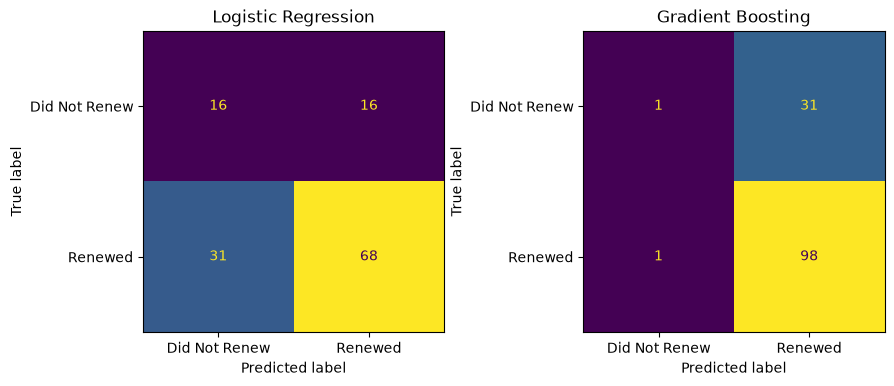

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay.from_predictions(y_test, logit_pred, display_labels=["Did Not Renew", "Renewed"], ax=ax[0], colorbar=False)
ax[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, gb_pred, display_labels=["Did Not Renew", "Renewed"], ax=ax[1], colorbar=False)
ax[1].set_title("Gradient Boosting")
plt.tight_layout()
plt.show()


## 6. What drives renewal? Feature importance

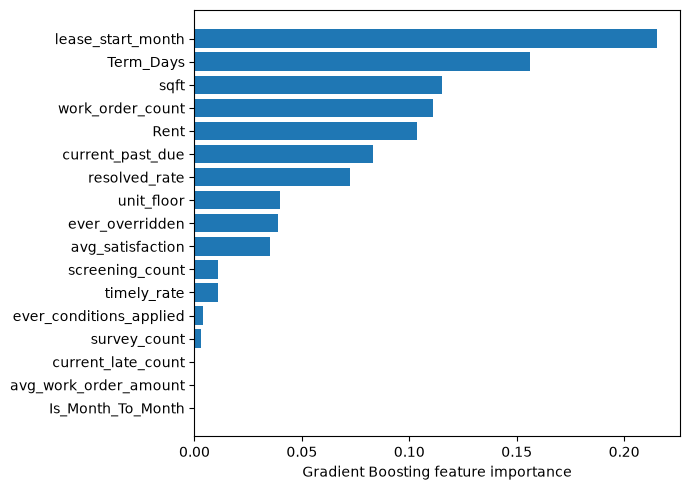

,feature,importance
12,lease_start_month,0.215232
0,Term_Days,0.156326
2,sqft,0.115261
10,work_order_count,0.110831
1,Rent,0.103497
3,current_past_due,0.083141
7,resolved_rate,0.072612
16,unit_floor,0.040031
15,ever_overridden,0.039052
6,avg_satisfaction,0.035257


In [23]:
feat_names = numeric_features + binary_features + categorical_features

gb_importances = gb.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": gb_importances}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
ax.set_xlabel("Gradient Boosting feature importance")
plt.tight_layout()
plt.show()
imp_df


In [24]:
coefs = logit.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs}).sort_values("coef", ascending=False)
print("Logistic regression coefficients (positive = pushes toward renewal):")
coef_df


Logistic regression coefficients (positive = pushes toward renewal):


,feature,coef
15,ever_overridden,0.393577
2,sqft,0.352771
12,lease_start_month,0.264980
6,avg_satisfaction,0.154375
0,Term_Days,0.103771
8,timely_rate,0.073649
4,current_late_count,0.071770
5,screening_count,0.032924
7,resolved_rate,0.031970
9,survey_count,0.007308


## 6b. A more honest way to measure what matters: averaged partial dependence

The feature-importance chart above has a blind spot: it summarizes splits across the whole ensemble
(impurity importance), which doesn't say *which direction* a feature pushes, and an earlier version of this
notebook's "what moves the prediction" analysis measured each field's effect from a single hypothetical
"typical tenant" baseline -- which turned out to be misleading (it made `Rent` look like the strongest
*negative* driver of renewal before the zero-rent leak above was found and fixed).

The fix is to average the model's prediction across **every** lease in the training data while varying just
one field at a time (a proper partial dependence curve), rather than picking one hypothetical baseline
tenant.

In [25]:
def averaged_pdp(feature, value, rows):
    """Average predicted probability across every row, with `feature` overridden to `value`."""
    overridden = rows.copy()
    overridden[feature] = value
    return gb.predict_proba(overridden[features])[:, 1].mean()

pdp_rows = model_df.copy()
pdp_results = []
for feat in numeric_features + categorical_features:
    lo, hi = model_df[feat].quantile(0.05), model_df[feat].quantile(0.95)
    if feat == "lease_start_month":
        lo, hi = 1, 9  # the real seasonal extremes (January vs September)
    p_lo = averaged_pdp(feat, lo, pdp_rows)
    p_hi = averaged_pdp(feat, hi, pdp_rows)
    pdp_results.append((feat, lo, hi, p_lo, p_hi, p_hi - p_lo))
for feat in binary_features:
    p_lo = averaged_pdp(feat, 0, pdp_rows)
    p_hi = averaged_pdp(feat, 1, pdp_rows)
    pdp_results.append((feat, 0, 1, p_lo, p_hi, p_hi - p_lo))

pdp_df = pd.DataFrame(pdp_results, columns=["feature", "low", "high", "prob_low", "prob_high", "swing"])
pdp_df = pdp_df.reindex(pdp_df.swing.abs().sort_values(ascending=False).index).reset_index(drop=True)
pdp_df


,feature,low,high,prob_low,prob_high,swing
0,lease_start_month,1.0,9.00,0.666673,0.800329,0.133656
1,sqft,580.0,976.00,0.661174,0.777620,0.116445
2,resolved_rate,0.0,1.00,0.691094,0.763860,0.072765
3,work_order_count,2.0,34.35,0.786557,0.721615,-0.064942
4,Term_Days,176.0,720.00,0.853879,0.797486,-0.056393
5,unit_floor,11.0,25.00,0.783388,0.731035,-0.052353
6,avg_satisfaction,1.0,5.00,0.727668,0.758890,0.031222
7,current_past_due,0.0,100.16,0.779501,0.808002,0.028501
8,ever_overridden,0.0,1.00,0.735666,0.761327,0.025661
9,Rent,1325.0,2302.75,0.736574,0.755282,0.018708


With unit size added and the zero-rent leak fixed, the ranking is:

- **Lease-start month is still the strongest, most trustworthy signal** -- unchanged through every
  correction so far. Leases starting late spring through early fall renew noticeably more often than winter
  starts.
- **Square footage is a real, second-strongest driver** (~12pt swing): bigger units renew more often. This
  makes sense and is worth trusting more than most other fields here, since `sqft` is populated for 100% of
  records (joined by unit number, not tenant name) -- no missing-data caveats apply.
- Unit floor and term length have modest negative effects; a handful of survey/screening fields have small
  positive effects.
- Rent's effect remains small after the leak fix -- essentially flat, slightly positive, nothing like the
  dominant negative driver an earlier, buggy version of this analysis reported.

**Lesson:** when a tree-ensemble feature looks like the dominant driver, check it two ways before trusting
it -- (1) does it hold up under averaged partial dependence, not just one baseline point, and (2) is there a
plausible data-artifact explanation (like a stray sentinel value tied to an already-excluded leaky column)
for why it might be extreme? Both checks caught something in this dataset.

## 7. Takeaways

This model went through several corrections, each of which changed what looked like the answer:

1. **v1 (default hyperparameters) was badly overfit** -- 97% training accuracy vs. 72% on unseen data. It
   had memorized noise, producing a jagged, non-monotonic relationship for work-order count and a 62-point
   swing for month-to-month status that was pure artifact.
2. **v2 regularized the model** (shallower trees, minimum leaf size, row subsampling) -- accuracy on unseen
   data barely changed, but the overfit noise disappeared. It still measured "what matters" from a single
   hypothetical median tenant, which distorted rent and term length.
3. **v3 found and fixed a second leak**: every `Rent == 0` row was actually a unit-transfer record where the
   new rent was never entered -- not a real $0 apartment -- and switched to properly-averaged partial
   dependence instead of a single baseline point.
4. **v4 (this version) fixed a compound-surname name-matching bug** that was silently undercounting
   screening/payment coverage for tenants with multi-word surnames, and **added unit square footage** as a
   feature -- joined by unit number rather than tenant name, so it isn't subject to any of the name-matching
   problems at all, and turned out to be the second-strongest driver in the model.

**What's left, and how much to trust it:**
- **Lease-start month (seasonality)** is the one finding that has survived every correction unchanged --
  leases starting late spring through early fall renew noticeably more than winter starts. This is the most
  trustworthy signal in the model.
- **Square footage** is the other genuinely trustworthy finding: bigger units renew more, and unlike almost
  everything else here, it's fully observed (100% coverage) rather than reconstructed from a partial join.
- **Rent, term length, and unit floor** have real but modest effects, and rent's direction reversed entirely
  once the zero-rent leak was fixed -- treat these as suggestive, not as levers to pull with confidence.
- **Satisfaction, work orders, and payment history individually move the estimate only a few points.**
  Payment history and satisfaction surveys are missing for well over half of training rows and fall back
  to a flat median -- that's a real data-coverage limit, not a modeling failure. Screening data is now
  well covered (~99%) after the compound-surname fix, but still shows almost no effect on its own --
  in this dataset, screening results genuinely don't predict renewal much once lease terms and unit
  size are accounted for.
- `resident_requested_count` was dropped entirely: it's 0 for every one of the 545 anonymized records.
  `bedrooms`/`bathrooms` were dropped after confirming a trained model never split on them (redundant with
  `sqft`). All three are retained in `renewal_features_anonymized.csv` for transparency.
- **Two fields were deliberately excluded** (`Previous Rent`/`Percent Difference`/`Dollar Difference` and
  `Tenant Transfer`) because they are populated *as a consequence of* a renewal happening, not observable
  beforehand.
- **Name matching is exact, not fuzzy** -- it fixes systematic formatting differences (comma vs. no-comma,
  compound surnames) but cannot catch a genuinely wrong name entered in the source system (see section 1b).
  Such errors fail silently as missing data, not as visible mismatches.
- All personally identifying fields were removed before this notebook ever sees the data (see
  `data/README.md`), and the notebook's own output contains only the anonymous `tenant_id`.

**Bottom line:** with ~522-545 rows, this dataset reliably supports a seasonality-and-unit-size view of
renewal, plus modest, directional signal on rent/term/floor. Treat those as hints, not levers -- and lean on
seasonality and square footage, the two results that held up to every check applied here.